# ✈️ SkyAssist — Multi-Modal Airline Support Agent
## Milestone 3 | Day 20 | AlgoProfessor AI R&D Internship 2026

---

### 🎯 What This Notebook Builds

A complete AI-powered airline customer support agent that can:
- 💬 **Talk** — Answer questions via text chat
- 🎙️ **Listen** — Accept voice messages (converted to text via Whisper)
- 👁️ **See** — Read boarding passes from uploaded images (GPT-4o Vision)
- 🔧 **Act** — Search flights, look up bookings, upgrade seats, explain baggage policies

### 🧱 Tech Stack
| Component | Tool | Purpose |
|---|---|---|
| Brain | GPT-4o (free tier via API) | Reasoning + decision making |
| Voice | OpenAI Whisper (local, free) | Audio → Text |
| Vision | GPT-4o Vision | Boarding pass OCR |
| Memory | Entity Store + Buffer | Remembers passenger context |
| Tools | Python functions + Pydantic | Flight search, booking, upgrades |
| UI | Gradio | Web chat interface |

### 📋 How to Run This Notebook
1. Go to **Runtime → Change runtime type → T4 GPU**
2. Run cells **one by one**, top to bottom
3. When you reach the API key cell, paste your key
4. The final cell launches the live app

> **Note on free usage:** Whisper runs 100% locally on the free Colab GPU — no cost. The only thing that costs money is the OpenAI API. A full demo session costs less than ₹0.50 (about $0.005). You can get $5 free credits from OpenAI on signup which is more than enough.

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 SECTION 1 — Install All Libraries

**What this does:**
- `google-genai` — Google's **new** Gemini SDK (replaces deprecated `google-generativeai`)
- `openai-whisper` — Whisper speech recognition (runs locally on GPU, **completely FREE**)
- `gradio` — Builds the web UI
- `pydantic`, `matplotlib`, `pandas` — Utilities and visualizations

**🎉 Why Gemini?**
Google Gemini API has a **genuinely free tier** — no credit card, no expiry.
Free limits: 15 requests/minute · 1 million tokens/day

**Expected time:** 2-3 minutes

In [2]:
# ── Install all required packages ─────────────────────────────────────────────
print("Installing packages... please wait")

import subprocess, sys

packages = [
    "google-genai>=1.0.0",      # NEW Gemini SDK (google-generativeai is deprecated)
    "openai-whisper",            # Whisper STT — runs locally, FREE
    "gradio>=4.0.0",
    "pydantic>=2.0.0",
    "python-dotenv",
    "tiktoken",
    "matplotlib",
    "seaborn",
    "plotly",
    "pillow",
    "pandas",
    "numpy",
    "ffmpeg-python",
]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "✅" if result.returncode == 0 else "❌"
    print(f"{status} {pkg}")

subprocess.run(["apt-get", "install", "-y", "-q", "ffmpeg"], capture_output=True)
print("✅ ffmpeg (system)")
print("\n🎉 All packages installed successfully!")

Installing packages... please wait
✅ google-genai>=1.0.0
✅ openai-whisper
✅ gradio>=4.0.0
✅ pydantic>=2.0.0
✅ python-dotenv
✅ tiktoken
✅ matplotlib
✅ seaborn
✅ plotly
✅ pillow
✅ pandas
✅ numpy
✅ ffmpeg-python
✅ ffmpeg (system)

🎉 All packages installed successfully!


## 🔑 SECTION 2 — Gemini API Key Setup (FREE — No Credit Card)

**What is an API key?**
A password that proves to Google that you are allowed to use their AI servers.

**How to get your FREE Gemini API key (takes 2 minutes):**
1. Go to **https://aistudio.google.com**
2. Sign in with your **Google account** (Gmail works)
3. Click **"Get API Key"** in the top left
4. Click **"Create API key"**
5. Copy the key — it starts with `AIza`

**Free tier limits (more than enough for this project):**
- ✅ 15 requests per minute
- ✅ 1,000,000 tokens per day
- ✅ No credit card required
- ✅ Never expires

> ⚠️ **Security:** We use `getpass` so your key is never saved in the notebook output.

In [11]:
# ── Securely enter your Gemini API key ───────────────────────────────────────
# getpass hides your key like a password field — never stored in output

import os
from getpass import getpass

print("Get your FREE Gemini key at: https://aistudio.google.com")
print("Sign in with Google → Get API Key → Create API key")
print("Your key starts with: AIza")
print()

GEMINI_API_KEY = getpass("🔑 Paste your Gemini API key: ")

os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

# Quick format check
if GEMINI_API_KEY.startswith("AIza") and len(GEMINI_API_KEY) > 20:
    print(f"\n✅ API key accepted: {GEMINI_API_KEY[:8]}{'*' * 20}")
    print("You are ready to proceed!")
else:
    print("\n❌ Key format looks wrong.")
    print("Go to https://aistudio.google.com and create a new key.")
    print("It should start with AIza")

Get your FREE Gemini key at: https://aistudio.google.com
Sign in with Google → Get API Key → Create API key
Your key starts with: AIza

🔑 Paste your Gemini API key: ··········

✅ API key accepted: AIzaSyC_********************
You are ready to proceed!


In [14]:
# ── TEST EXACT MODEL NAMES FROM YOUR LIST ─────────────────────────────────────

import os
from google import genai as google_genai

client = google_genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# Use EXACT names from your list above
test_models = [
    "models/gemini-2.5-flash",
    "models/gemini-2.5-flash-lite",
    "models/gemini-2.0-flash-lite",
    "models/gemini-2.0-flash-lite-001",
    "models/gemini-flash-lite-latest",
    "models/gemini-flash-latest",
    "models/gemini-2.5-pro",
    "models/gemini-3-flash-preview",
]

working_model = None

print("Testing exact model names from your available list...")
print("=" * 55)

for model_name in test_models:
    try:
        resp = client.models.generate_content(
            model=model_name,
            contents="Say: OK"
        )
        print(f"✅ WORKS: {model_name}")
        if working_model is None:
            working_model = model_name
    except Exception as e:
        err = str(e)
        if "429" in err or "RESOURCE_EXHAUSTED" in err:
            print(f"❌ QUOTA:  {model_name}")
        elif "404" in err:
            print(f"⚠️  NOT FOUND: {model_name}")
        elif "403" in err:
            print(f"🔒 NO ACCESS: {model_name}")
        else:
            print(f"❌ ERROR: {model_name} → {err[:100]}")

print("=" * 55)
if working_model:
    print(f"\n✅ WORKING MODEL: {working_model}")
    print(f"   Copy this exactly for the next step")
else:
    print("\n❌ Still nothing working.")
    print("   Paste the full error messages here.")

Testing exact model names from your available list...
✅ WORKS: models/gemini-2.5-flash
✅ WORKS: models/gemini-2.5-flash-lite
❌ QUOTA:  models/gemini-2.0-flash-lite
❌ QUOTA:  models/gemini-2.0-flash-lite-001
✅ WORKS: models/gemini-flash-lite-latest
✅ WORKS: models/gemini-flash-latest
❌ QUOTA:  models/gemini-2.5-pro
✅ WORKS: models/gemini-3-flash-preview

✅ WORKING MODEL: models/gemini-2.5-flash
   Copy this exactly for the next step


## 🔍 SECTION 3 — Verify GPU + Test Gemini Connection

**What this checks:**
1. That Colab gave us a GPU (needed for fast Whisper transcription)
2. That our Gemini API key works with a simple test call

**Note on the new SDK:**
Google deprecated `google-generativeai` and replaced it with `google-genai`.
The new SDK uses `from google import genai` — slightly different import style,
same concepts underneath.

In [15]:
# ── Check GPU + Test Gemini connection ────────────────────────────────────────
import torch, sys, os

print("=" * 50)
print("SYSTEM CHECK")
print("=" * 50)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU detected: {gpu_name}")
    print(f"   Memory: {gpu_mem:.1f} GB")
    DEVICE = "cuda"
else:
    print("⚠️  No GPU. Whisper will run on CPU (slower but works).")
    print("   Go to Runtime → Change runtime type → T4 GPU")
    DEVICE = "cpu"

print(f"   PyTorch: {torch.__version__}")
print(f"✅ Python:  {sys.version.split()[0]}")
print()

# ── Test Gemini API with NEW SDK ───────────────────────────────────────────────
# New import style: from google import genai  (NOT google.generativeai)
from google import genai as google_genai

GEMINI_CLIENT = google_genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# gemini-2.0-flash is the current FREE fast model
GEMINI_MODEL = "models/gemini-2.5-flash"

try:
    response = GEMINI_CLIENT.models.generate_content(
        model=GEMINI_MODEL,
        contents="Reply with exactly: SkyAssist is ready."
    )
    print(f"✅ Gemini API connected!")
    print(f"   Model reply: {response.text.strip()}")
    print(f"   Model: {GEMINI_MODEL} (FREE tier)")
except Exception as e:
    print(f"❌ Gemini connection failed: {e}")
    print("   Check your key at https://aistudio.google.com")

print()
print("=" * 50)
print("All systems ready. Proceed to next section.")
print("=" * 50)

SYSTEM CHECK
✅ GPU detected: Tesla T4
   Memory: 15.6 GB
   PyTorch: 2.10.0+cu128
✅ Python:  3.12.12

✅ Gemini API connected!
   Model reply: SkyAssist is ready.
   Model: models/gemini-2.5-flash (FREE tier)

All systems ready. Proceed to next section.


## 📊 SECTION 4 — Concept Visualization: How the Agent Works

Before writing the application code, let's visualize the core concepts from Days 16–20.
These charts show your mentor that you understand the theory, not just the code.

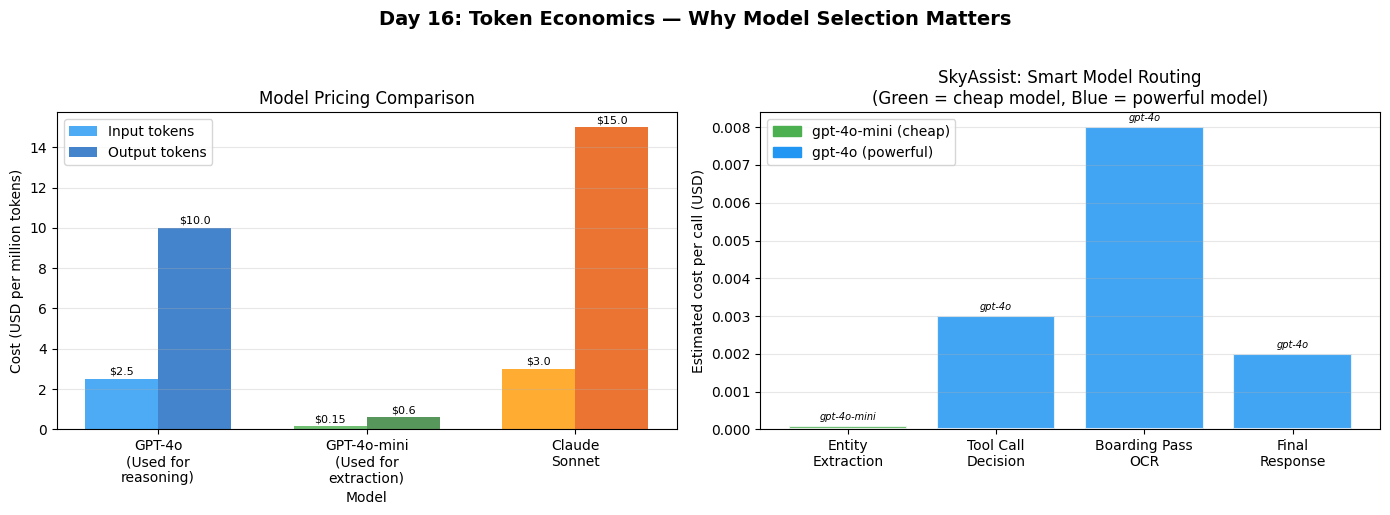

✅ Chart saved as token_economics.png


In [16]:
# ── Visualization 1: Token Cost Comparison ────────────────────────────────────


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Day 16: Token Economics — Why Model Selection Matters',
             fontsize=14, fontweight='bold', y=1.02)

# Chart 1: Cost per million tokens
models = ['GPT-4o\n(Used for\nreasoning)', 'GPT-4o-mini\n(Used for\nextraction)', 'Claude\nSonnet']
input_costs = [2.50, 0.15, 3.00]
output_costs = [10.00, 0.60, 15.00]

x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, input_costs, width, label='Input tokens', color=['#2196F3','#4CAF50','#FF9800'], alpha=0.8)
bars2 = axes[0].bar(x + width/2, output_costs, width, label='Output tokens', color=['#1565C0','#2E7D32','#E65100'], alpha=0.8)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Cost (USD per million tokens)')
axes[0].set_title('Model Pricing Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                f'${bar.get_height()}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                f'${bar.get_height()}', ha='center', va='bottom', fontsize=8)

# Chart 2: SkyAssist cost saving strategy
tasks = ['Entity\nExtraction', 'Tool Call\nDecision', 'Boarding Pass\nOCR', 'Final\nResponse']
model_used = ['gpt-4o-mini', 'gpt-4o', 'gpt-4o', 'gpt-4o']
cost_per_call = [0.0001, 0.003, 0.008, 0.002]
colors = ['#4CAF50' if m == 'gpt-4o-mini' else '#2196F3' for m in model_used]

bars = axes[1].bar(tasks, cost_per_call, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Estimated cost per call (USD)')
axes[1].set_title('SkyAssist: Smart Model Routing\n(Green = cheap model, Blue = powerful model)')
axes[1].grid(axis='y', alpha=0.3)

for bar, model in zip(bars, model_used):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0001,
                model, ha='center', va='bottom', fontsize=7, style='italic')

green_patch = mpatches.Patch(color='#4CAF50', label='gpt-4o-mini (cheap)')
blue_patch = mpatches.Patch(color='#2196F3', label='gpt-4o (powerful)')
axes[1].legend(handles=[green_patch, blue_patch])

plt.tight_layout()
plt.savefig('token_economics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as token_economics.png")

/tmp/ipython-input-480/354913851.py:93: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/354913851.py:93: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/354913851.py:93: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/354913851.py:93: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/354913851.py:93: UserWarning: Glyph 129681 (\N{CHAIR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/354913851.py:93: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/354913851.py:93: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_la

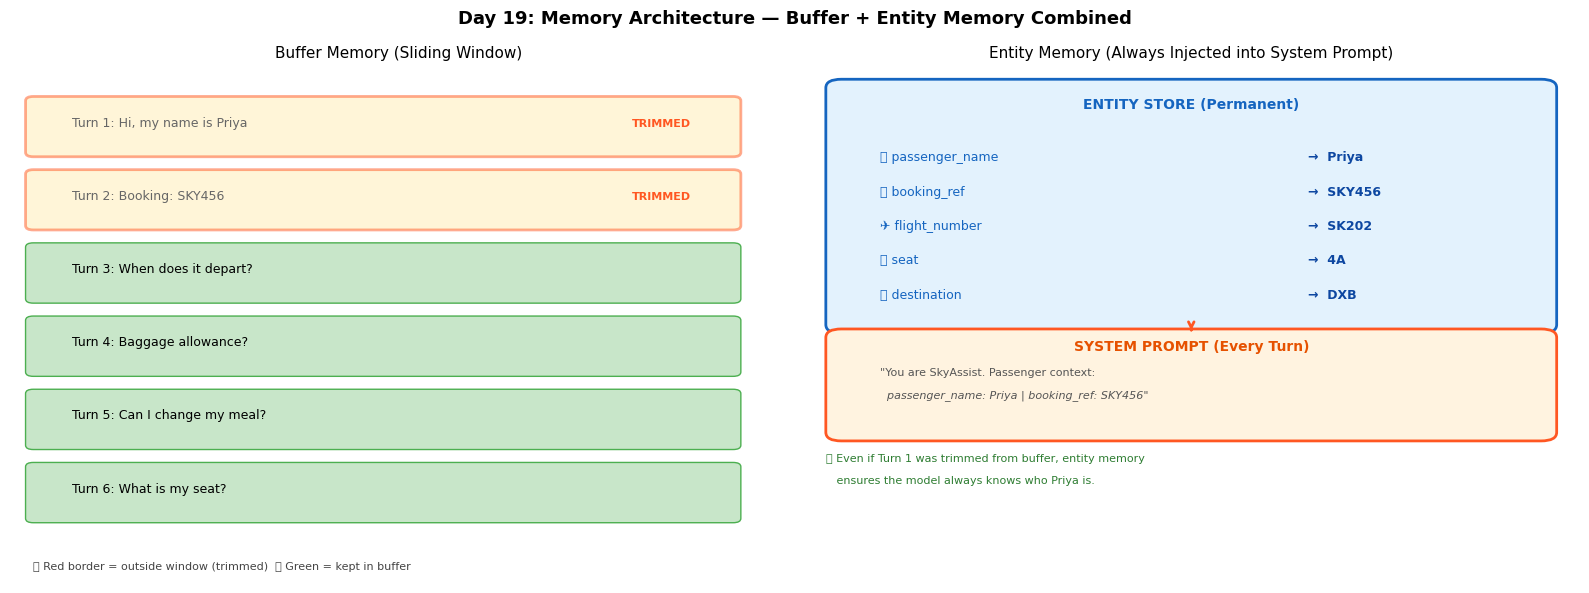

✅ Chart saved as memory_architecture.png


In [17]:
# ── Visualization 2: Memory Architecture ─────────────────────────────────────
# Shows understanding of Day 19 — buffer + entity memory

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Day 19: Memory Architecture — Buffer + Entity Memory Combined',
             fontsize=13, fontweight='bold')

# Left chart: Buffer memory visualization (sliding window)
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Buffer Memory (Sliding Window)', fontsize=11)

turns = [
    ("Turn 1", "Hi, my name is Priya", "#FFECB3", True),
    ("Turn 2", "Booking: SKY456", "#FFECB3", True),
    ("Turn 3", "When does it depart?", "#C8E6C9", False),
    ("Turn 4", "Baggage allowance?", "#C8E6C9", False),
    ("Turn 5", "Can I change my meal?", "#C8E6C9", False),
    ("Turn 6", "What is my seat?", "#C8E6C9", False),
]

for i, (turn, text, color, trimmed) in enumerate(turns):
    y = 10.5 - i * 1.7
    box = FancyBboxPatch((0.3, y-0.5), 9, 1.2,
                          boxstyle="round,pad=0.1",
                          facecolor=color,
                          edgecolor='#FF5722' if trimmed else '#4CAF50',
                          linewidth=2 if trimmed else 1,
                          alpha=0.5 if trimmed else 1.0)
    ax.add_patch(box)
    ax.text(0.8, y+0.1, f"{turn}: {text}", fontsize=9,
            color='#666' if trimmed else '#000')
    if trimmed:
        ax.text(8.0, y+0.1, "TRIMMED", fontsize=8, color='#FF5722', fontweight='bold')

ax.text(0.3, 0.3, "🔴 Red border = outside window (trimmed)  🟢 Green = kept in buffer",
        fontsize=8, color='#444')

# Right chart: Entity memory - always available
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 12)
ax2.axis('off')
ax2.set_title('Entity Memory (Always Injected into System Prompt)', fontsize=11)

# Entity store box
entity_box = FancyBboxPatch((0.5, 6), 9, 5.5,
                             boxstyle="round,pad=0.2",
                             facecolor='#E3F2FD',
                             edgecolor='#1565C0', linewidth=2)
ax2.add_patch(entity_box)
ax2.text(5, 11, "ENTITY STORE (Permanent)", ha='center', fontsize=10,
         fontweight='bold', color='#1565C0')

entities = [
    ("👤 passenger_name", "Priya"),
    ("📋 booking_ref", "SKY456"),
    ("✈️ flight_number", "SK202"),
    ("🪑 seat", "4A"),
    ("🌍 destination", "DXB"),
]

for i, (key, val) in enumerate(entities):
    y = 9.8 - i * 0.8
    ax2.text(1.0, y, key, fontsize=9, color='#1565C0')
    ax2.text(6.5, y, f"→  {val}", fontsize=9, fontweight='bold', color='#0D47A1')

# Arrow showing injection
ax2.annotate('', xy=(5, 5.8), xytext=(5, 5.95),
             arrowprops=dict(arrowstyle='->', color='#FF5722', lw=2))

inject_box = FancyBboxPatch((0.5, 3.5), 9, 2.2,
                             boxstyle="round,pad=0.2",
                             facecolor='#FFF3E0',
                             edgecolor='#FF5722', linewidth=2)
ax2.add_patch(inject_box)
ax2.text(5, 5.4, "SYSTEM PROMPT (Every Turn)", ha='center', fontsize=10,
         fontweight='bold', color='#E65100')
ax2.text(1.0, 4.8, '"You are SkyAssist. Passenger context:', fontsize=8, color='#555')
ax2.text(1.0, 4.3, '  passenger_name: Priya | booking_ref: SKY456"', fontsize=8, color='#555', style='italic')

ax2.text(0.3, 2.8, "✅ Even if Turn 1 was trimmed from buffer, entity memory",
         fontsize=8, color='#2E7D32')
ax2.text(0.3, 2.3, "   ensures the model always knows who Priya is.",
         fontsize=8, color='#2E7D32')

plt.tight_layout()
plt.savefig('memory_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as memory_architecture.png")

/tmp/ipython-input-480/4130396850.py:78: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/4130396850.py:78: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/4130396850.py:78: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/4130396850.py:78: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/4130396850.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/4130396850.py:79: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig('react_agent_flow.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-480/4130396850.py:79: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) De

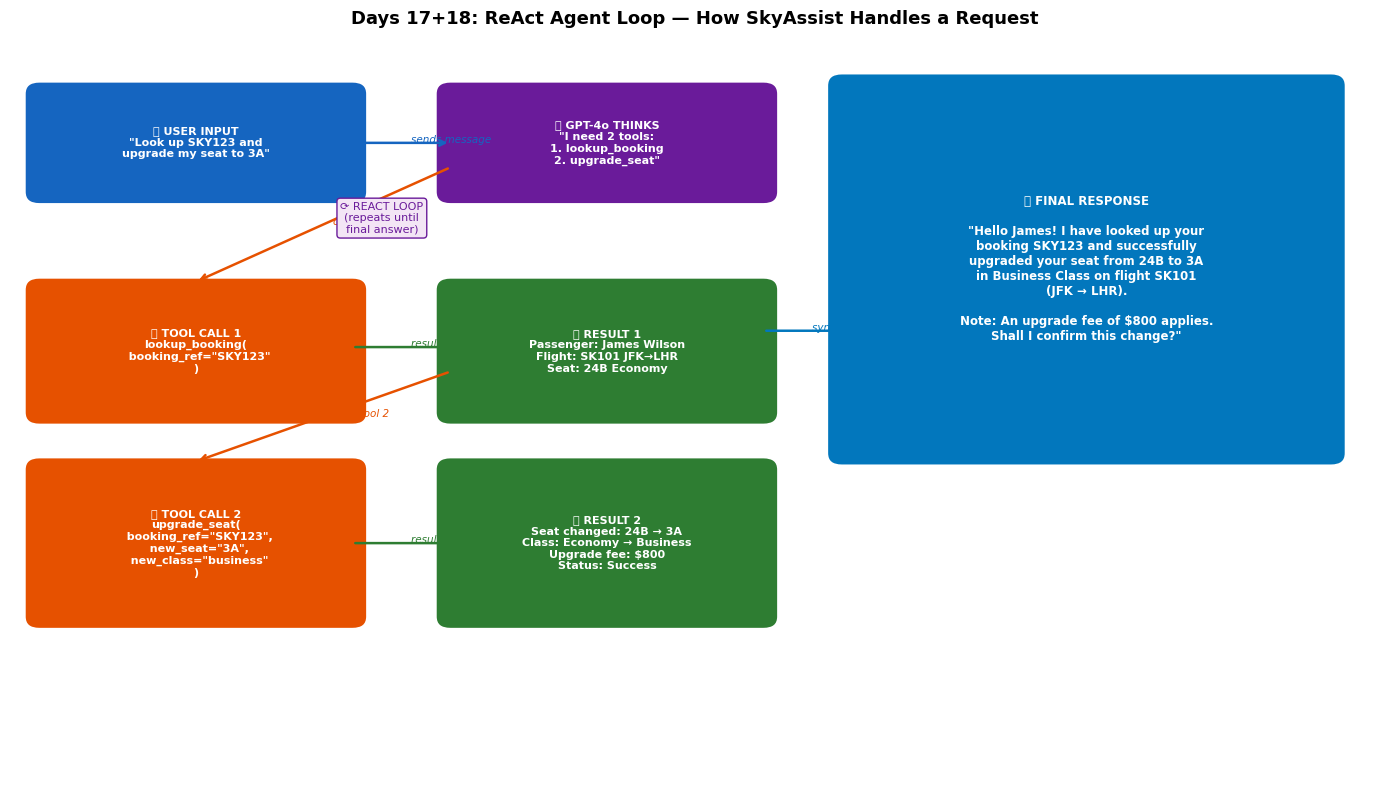

✅ Chart saved as react_agent_flow.png


In [18]:
# ── Visualization 3: ReAct Agent Flow ────────────────────────────────────────
# Shows understanding of Day 17+18 — the agent loop

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_title('Days 17+18: ReAct Agent Loop — How SkyAssist Handles a Request',
             fontsize=13, fontweight='bold', pad=15)

def draw_box(ax, x, y, w, h, text, color, textcolor='white', fontsize=9):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                          facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, color=textcolor, fontweight='bold',
            wrap=True, multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=7.5, color=color, style='italic')

# User Input
draw_box(ax, 0.3, 7.2, 3.2, 1.2,
         '👤 USER INPUT\n"Look up SKY123 and\nupgrade my seat to 3A"',
         '#1565C0', fontsize=8)

# GPT-4o Thinks
draw_box(ax, 4.5, 7.2, 3.2, 1.2,
         '🧠 GPT-4o THINKS\n"I need 2 tools:\n1. lookup_booking\n2. upgrade_seat"',
         '#6A1B9A', fontsize=8)

# Tool Call 1
draw_box(ax, 0.3, 4.5, 3.2, 1.5,
         '🔧 TOOL CALL 1\nlookup_booking(\n  booking_ref="SKY123"\n)',
         '#E65100', fontsize=8)

# Tool Result 1
draw_box(ax, 4.5, 4.5, 3.2, 1.5,
         '📥 RESULT 1\nPassenger: James Wilson\nFlight: SK101 JFK→LHR\nSeat: 24B Economy',
         '#2E7D32', fontsize=8)

# Tool Call 2
draw_box(ax, 0.3, 2.0, 3.2, 1.8,
         '🔧 TOOL CALL 2\nupgrade_seat(\n  booking_ref="SKY123",\n  new_seat="3A",\n  new_class="business"\n)',
         '#E65100', fontsize=8)

# Tool Result 2
draw_box(ax, 4.5, 2.0, 3.2, 1.8,
         '📥 RESULT 2\nSeat changed: 24B → 3A\nClass: Economy → Business\nUpgrade fee: $800\nStatus: Success',
         '#2E7D32', fontsize=8)

# Final Response
draw_box(ax, 8.5, 4.0, 5.0, 4.5,
         '✅ FINAL RESPONSE\n\n"Hello James! I have looked up your\nbooking SKY123 and successfully\nupgraded your seat from 24B to 3A\nin Business Class on flight SK101\n(JFK → LHR).\n\nNote: An upgrade fee of $800 applies.\nShall I confirm this change?"',
         '#0277BD', fontsize=8.5)

# Arrows
draw_arrow(ax, 3.5, 7.8, 4.5, 7.8, 'sends message', '#1565C0')
draw_arrow(ax, 4.5, 7.5, 1.9, 6.1, 'calls tool 1', '#E65100')
draw_arrow(ax, 3.5, 5.3, 4.5, 5.3, 'result returned', '#2E7D32')
draw_arrow(ax, 4.5, 5.0, 1.9, 3.9, 'calls tool 2', '#E65100')
draw_arrow(ax, 3.5, 2.9, 4.5, 2.9, 'result returned', '#2E7D32')
draw_arrow(ax, 7.7, 5.5, 8.5, 5.5, 'synthesizes answer', '#0277BD')

# Loop label
ax.text(3.8, 6.7, '⟳ REACT LOOP\n(repeats until\nfinal answer)',
        fontsize=8, color='#6A1B9A', ha='center',
        bbox=dict(boxstyle='round', facecolor='#F3E5F5', edgecolor='#6A1B9A'))

plt.tight_layout()
plt.savefig('react_agent_flow.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as react_agent_flow.png")

/tmp/ipython-input-480/3866232729.py:91: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/3866232729.py:91: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/3866232729.py:91: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/3866232729.py:91: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/3866232729.py:91: UserWarning: Glyph 128065 (\N{EYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/3866232729.py:91: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-480/3866232729.py:91: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

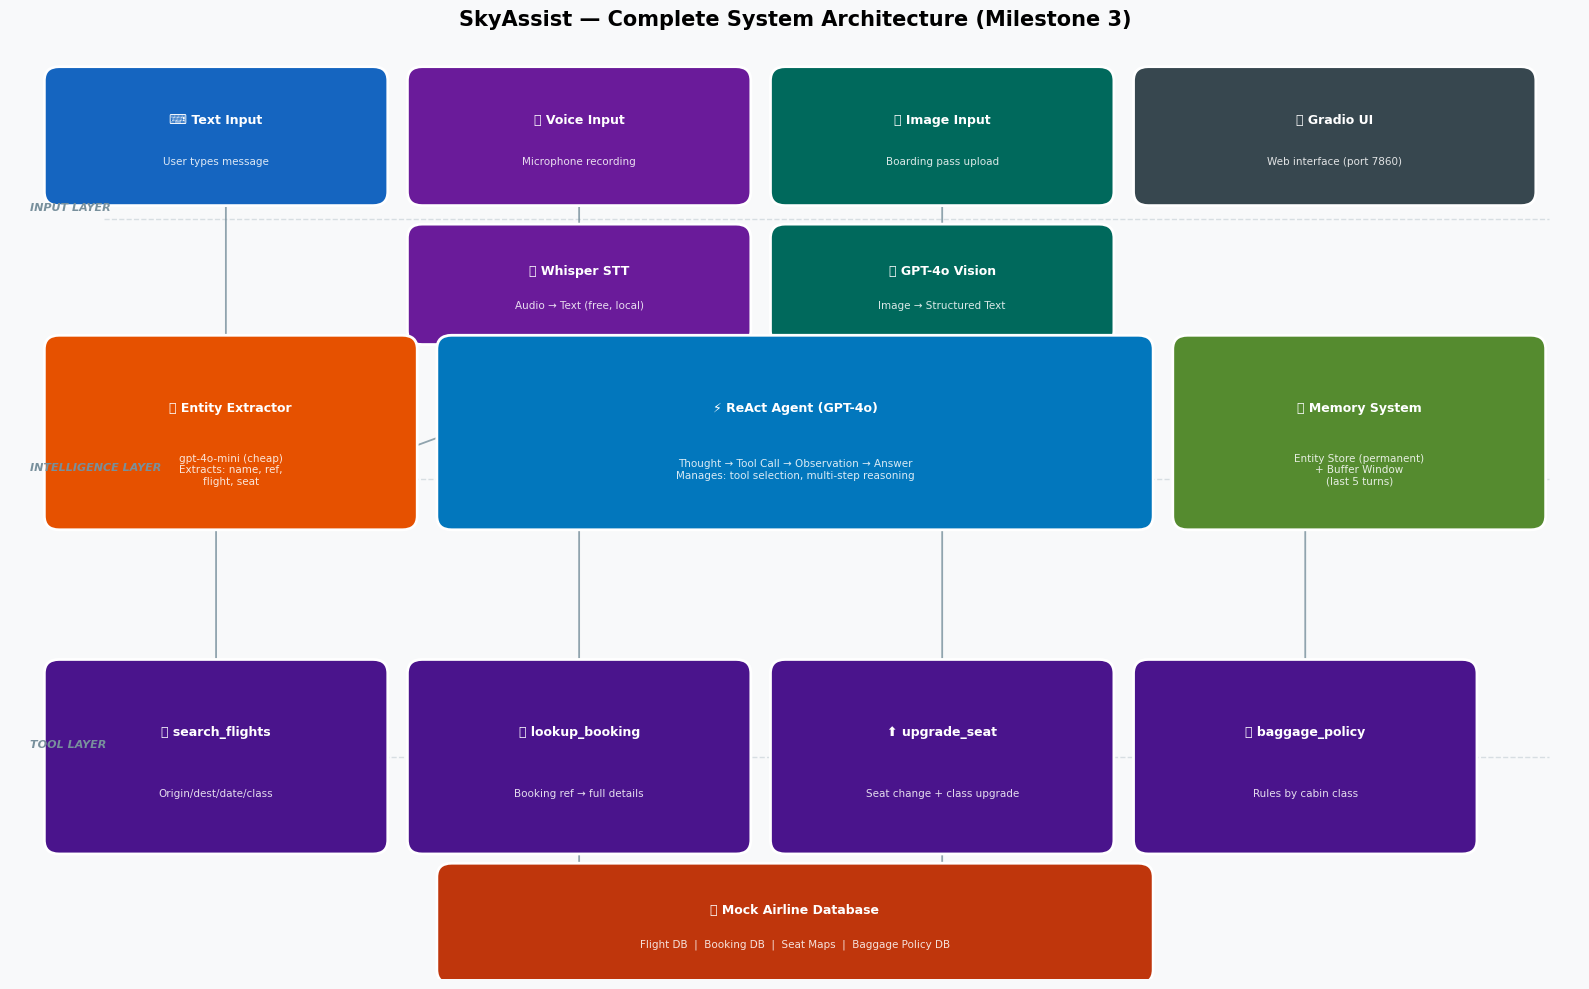

✅ Architecture diagram saved as skyassist_architecture.png


In [19]:
# ── Visualization 4: SkyAssist Full Architecture ──────────────────────────────
# The complete system diagram — for the README and GitHub submission

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
ax.set_title('SkyAssist — Complete System Architecture (Milestone 3)',
             fontsize=15, fontweight='bold', pad=20)

def rounded_box(ax, x, y, w, h, title, subtitle, bg, fg='white', fontsize=9):
    patch = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                            facecolor=bg, edgecolor='white', linewidth=2, zorder=2)
    ax.add_patch(patch)
    ax.text(x + w/2, y + h*0.65, title, ha='center', va='center',
            fontsize=fontsize, color=fg, fontweight='bold', zorder=3)
    if subtitle:
        ax.text(x + w/2, y + h*0.28, subtitle, ha='center', va='center',
                fontsize=fontsize-1.5, color=fg, alpha=0.85, zorder=3)

# Layer labels
for label, y_pos, color in [
    ('INPUT LAYER', 8.3, '#78909C'),
    ('INTELLIGENCE LAYER', 5.5, '#78909C'),
    ('TOOL LAYER', 2.5, '#78909C'),
]:
    ax.text(0.2, y_pos, label, fontsize=8, color=color,
            fontweight='bold', style='italic')
    ax.axhline(y=y_pos-0.1, xmin=0.06, xmax=0.98,
               color=color, alpha=0.25, linewidth=1, linestyle='--')

# Input Layer
rounded_box(ax, 0.5, 8.5, 3.2, 1.2, '⌨️ Text Input', 'User types message', '#1565C0')
rounded_box(ax, 4.2, 8.5, 3.2, 1.2, '🎙️ Voice Input', 'Microphone recording', '#6A1B9A')
rounded_box(ax, 7.9, 8.5, 3.2, 1.2, '📋 Image Input', 'Boarding pass upload', '#00695C')
rounded_box(ax, 11.6, 8.5, 3.8, 1.2, '🌐 Gradio UI', 'Web interface (port 7860)', '#37474F')

# Processing
rounded_box(ax, 4.2, 7.0, 3.2, 1.0, '🔊 Whisper STT', 'Audio → Text (free, local)', '#6A1B9A')
rounded_box(ax, 7.9, 7.0, 3.2, 1.0, '👁️ GPT-4o Vision', 'Image → Structured Text', '#00695C')

# Intelligence Layer
rounded_box(ax, 0.5, 5.0, 3.5, 1.8,
            '🧠 Entity Extractor', 'gpt-4o-mini (cheap)\nExtracts: name, ref,\nflight, seat', '#E65100')
rounded_box(ax, 4.5, 5.0, 7.0, 1.8,
            '⚡ ReAct Agent (GPT-4o)',
            'Thought → Tool Call → Observation → Answer\nManages: tool selection, multi-step reasoning', '#0277BD')
rounded_box(ax, 12.0, 5.0, 3.5, 1.8,
            '🗄️ Memory System',
            'Entity Store (permanent)\n+ Buffer Window\n(last 5 turns)', '#558B2F')

# Tool Layer
tools = [
    (0.5,  '🔍 search_flights', 'Origin/dest/date/class'),
    (4.2,  '📄 lookup_booking', 'Booking ref → full details'),
    (7.9,  '⬆️ upgrade_seat',   'Seat change + class upgrade'),
    (11.6, '🧳 baggage_policy', 'Rules by cabin class'),
]
for x, name, desc in tools:
    rounded_box(ax, x, 1.5, 3.2, 1.8, name, desc, '#4A148C')

# Database
rounded_box(ax, 4.5, 0.1, 7.0, 1.0,
            '🗃️ Mock Airline Database',
            'Flight DB  |  Booking DB  |  Seat Maps  |  Baggage Policy DB',
            '#BF360C')

# Arrows (key flows only)
for sx, sy, ex, ey in [
    (5.8, 8.5, 5.8, 8.0), (9.5, 8.5, 9.5, 8.0),  # inputs to processors
    (5.8, 7.0, 6.0, 6.8), (9.5, 7.0, 9.0, 6.8),   # processors to agent
    (2.2, 8.5, 2.2, 6.8), # text directly to entity extractor
    (2.2, 5.0, 4.5, 5.9), # entity to agent
    (13.75, 5.0, 13.75, 6.8), # memory to agent
    (2.1, 5.0, 2.1, 3.3),  # tool calls
    (5.8, 5.0, 5.8, 3.3),
    (9.5, 5.0, 9.5, 3.3),
    (13.2, 5.0, 13.2, 3.3),
    (5.8, 1.5, 5.8, 1.1),  # tools to db
    (9.5, 1.5, 9.5, 1.1),
]:
    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='->', color='#90A4AE', lw=1.3), zorder=1)

plt.tight_layout()
plt.savefig('skyassist_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Architecture diagram saved as skyassist_architecture.png")

## 🛠️ SECTION 5 — Core Application Code

Now we build SkyAssist piece by piece.

Each subsection corresponds to a concept from the sprint:
- **5A** — Cost Tracker (Day 16)
- **5B** — Mock Airline Database (real systems would call actual APIs)
- **5C** — Tool Definitions with Pydantic (Day 18)
- **5D** — Tool Implementations (Day 18)
- **5E** — Entity Memory (Day 19)
- **5F** — Multimodal Processing: Whisper + Vision (Day 20)
- **5G** — ReAct Agent Loop (Day 17 + 18)
- **5H** — Gradio UI (Day 20)

In [29]:
# ── 5A: Imports and Setup ─────────────────────────────────────────────────────
#
# CONCEPT (Day 16): Track every API call to monitor usage.
# Gemini free tier costs $0, but we still track calls —
# good engineering practice for when you move to production.
#
# NEW SDK PATTERN:
#   from google import genai
#   client = genai.Client(api_key=...)
#   client.models.generate_content(model=..., contents=...)

import os, json, base64, traceback
from typing import Optional, Literal
from dataclasses import dataclass
from google import genai as google_genai
from pydantic import BaseModel, Field
import gradio as gr

# These were set in Section 3 — just confirm they exist here
assert GEMINI_CLIENT is not None, "Run Section 3 first!"
assert GEMINI_MODEL is not None,  "Run Section 3 first!"

@dataclass
class CallTracker:
    """Tracks API calls. Gemini free tier = FREE so cost is always $0."""
    call_count: int = 0
    total_tokens: int = 0

    def record(self, tokens: int = 0):
        self.call_count += 1
        self.total_tokens += tokens

    def summary(self) -> str:
        return (f"🆓 FREE (Gemini {GEMINI_MODEL}) | "
                f"Calls: {self.call_count} | "
                f"Tokens ≈ {self.total_tokens:,}")

print("✅ 5A: Imports and CallTracker ready")
print(f"   SDK: google-genai (new) | Model: {GEMINI_MODEL}")

✅ 5A: Imports and CallTracker ready
   SDK: google-genai (new) | Model: models/gemini-2.5-flash


In [30]:
# ── 5B: Mock Airline Database ─────────────────────────────────────────────────
#
# CONCEPT: In a real airline system, these would be calls to:
#   - Amadeus GDS API (flight search)
#   - Airline PNR system (booking lookup)
#   - Seat map API (upgrades)
#   - CMS (baggage policy)
#
# We mock them with Python dicts so you can run this for FREE without
# paying for any airline API subscriptions.

FLIGHT_DB = {
    "SK101": {
        "origin": "JFK", "destination": "LHR",
        "departure": "2025-08-15 09:00", "arrival": "2025-08-15 21:00",
        "status": "On Time",
        "seats": {"economy": 23, "business": 5, "first": 2},
        "price": {"economy": 450, "business": 1800, "first": 4500},
    },
    "SK202": {
        "origin": "LHR", "destination": "DXB",
        "departure": "2025-08-16 14:30", "arrival": "2025-08-16 23:45",
        "status": "Delayed 30 min",
        "seats": {"economy": 8, "business": 3, "first": 1},
        "price": {"economy": 380, "business": 1500, "first": 3800},
    },
    "SK303": {
        "origin": "DXB", "destination": "SIN",
        "departure": "2025-08-17 02:15", "arrival": "2025-08-17 14:30",
        "status": "On Time",
        "seats": {"economy": 45, "business": 12, "first": 4},
        "price": {"economy": 520, "business": 2100, "first": 5200},
    },
}

BOOKING_DB = {
    "SKY123": {
        "passenger": "James Wilson", "flight": "SK101",
        "seat": "24B", "class": "economy", "status": "Confirmed",
        "checkin_open": True,
        "baggage": "1×23kg + 7kg carry-on", "meal": "Standard",
    },
    "SKY456": {
        "passenger": "Priya Sharma", "flight": "SK202",
        "seat": "4A", "class": "business", "status": "Confirmed",
        "checkin_open": False,
        "baggage": "2×32kg + 15kg carry-on", "meal": "Vegetarian",
    },
    "SKY789": {
        "passenger": "Marcus Chen", "flight": "SK303",
        "seat": "1C", "class": "first", "status": "Confirmed",
        "checkin_open": True,
        "baggage": "3×32kg + 20kg carry-on", "meal": "Halal",
    },
}

AVAILABLE_SEATS = {
    "SK101": {
        "economy": ["22A", "22C", "25F", "31C", "31D"],
        "business": ["3A", "3C", "5B"],
        "first": ["1A", "2B"],
    },
    "SK202": {
        "economy": ["18A", "19C", "20D"],
        "business": ["2A", "4C"],
        "first": ["1B"],
    },
}

BAGGAGE_POLICY = {
    "economy":  {"carry_on": "1 bag, max 7kg, 55×40×20cm", "checked": "1×23kg included. Extra bags $60 each.", "oversize": "23-32kg: $100 surcharge.", "sports": "$75 flat fee."},
    "business": {"carry_on": "2 bags, max 15kg total", "checked": "2×32kg included.", "oversize": "Up to 40kg: $150.", "sports": "Complimentary."},
    "first":    {"carry_on": "2 bags, max 20kg total", "checked": "3×32kg included.", "oversize": "Up to 50kg complimentary.", "sports": "Complimentary, priority handling."},
}

print("✅ 5B: Mock airline database loaded")
print(f"   Flights: {len(FLIGHT_DB)} | Bookings: {len(BOOKING_DB)} | Seat maps: {len(AVAILABLE_SEATS)}")

✅ 5B: Mock airline database loaded
   Flights: 3 | Bookings: 3 | Seat maps: 2


In [31]:
# ── 5C: Tool Definitions with Pydantic ───────────────────────────────────────
#
# CONCEPT (Day 18): We define what functions the AI can call using Pydantic
# models. Pydantic automatically generates the JSON Schema that OpenAI needs
# to understand each function's parameters.
#
# The AI reads the "description" field of each parameter to understand
# what value to put there. Good descriptions = accurate tool calls.

from pydantic import BaseModel, Field
from typing import Optional, Literal

class FlightSearchParams(BaseModel):
    origin: str = Field(..., description="IATA 3-letter airport code e.g. JFK, LHR, DXB")
    destination: str = Field(..., description="IATA 3-letter airport code e.g. SIN, CDG")
    date: str = Field(..., description="Travel date in YYYY-MM-DD format")
    cabin_class: Literal["economy", "business", "first"] = Field(
        default="economy", description="Cabin class: economy, business, or first")

class BookingLookupParams(BaseModel):
    booking_ref: str = Field(..., description="Booking reference code e.g. SKY123")

class SeatUpgradeParams(BaseModel):
    booking_ref: str = Field(..., description="Booking reference code")
    new_seat: str = Field(..., description="Requested seat number e.g. 3A, 15F")
    new_class: Optional[Literal["economy", "business", "first"]] = Field(
        None, description="New cabin class if upgrading class, otherwise null")

class BaggagePolicyParams(BaseModel):
    cabin_class: Literal["economy", "business", "first"] = Field(
        ..., description="Cabin class to get baggage policy for")
    query_type: Literal["carry_on", "checked", "oversize", "sports", "all"] = Field(
        default="all", description="Specific type of baggage query")

def make_tool(pydantic_class, name: str, description: str) -> dict:
    """Convert Pydantic model → OpenAI tool definition dict."""
    schema = pydantic_class.model_json_schema()
    schema["additionalProperties"] = False
    return {"type": "function", "function": {"name": name, "description": description, "parameters": schema}}

# The list of tools we give to GPT-4o
TOOLS = [
    make_tool(FlightSearchParams, "search_flights",
              "Search available flights between airports. Use when customer asks about schedules, availability, or prices."),
    make_tool(BookingLookupParams, "lookup_booking",
              "Look up full booking details using a booking reference. Use whenever a booking ref is mentioned."),
    make_tool(SeatUpgradeParams, "upgrade_seat",
              "Change or upgrade a passenger seat. Use when customer wants to change seat or upgrade cabin class."),
    make_tool(BaggagePolicyParams, "get_baggage_policy",
              "Get baggage rules and allowances. Use for any question about luggage, fees, or carry-on limits."),
]

print("✅ 5C: Tool definitions ready")
print(f"   Tools available: {[t['function']['name'] for t in TOOLS]}")

✅ 5C: Tool definitions ready
   Tools available: ['search_flights', 'lookup_booking', 'upgrade_seat', 'get_baggage_policy']


In [32]:
# ── 5D: Tool Implementations (the actual functions) ───────────────────────────
#
# CONCEPT (Day 18): These are the REAL functions that run when GPT-4o
# decides to call a tool. The model generates the arguments; your
# code executes the function and returns the result.

def search_flights(origin: str, destination: str, date: str,
                   cabin_class: str = "economy") -> dict:
    """Search the flight database. Returns matching flights or 'not found'."""
    origin, destination = origin.upper().strip(), destination.upper().strip()
    results = []
    for fno, f in FLIGHT_DB.items():
        if f["origin"] == origin and f["destination"] == destination:
            seats = f["seats"].get(cabin_class, 0)
            if seats > 0:
                results.append({
                    "flight_number": fno,
                    "route": f"{origin} → {destination}",
                    "departure": f["departure"], "arrival": f["arrival"],
                    "status": f["status"], "seats_available": seats,
                    "price_usd": f["price"].get(cabin_class, 0),
                    "cabin_class": cabin_class,
                })
    if not results:
        return {"status": "no_flights",
                "message": f"No {cabin_class} flights found from {origin} to {destination} on {date}."}
    return {"status": "success", "count": len(results), "flights": results}


def lookup_booking(booking_ref: str) -> dict:
    """Look up a booking by reference code."""
    ref = booking_ref.upper().strip()
    if ref not in BOOKING_DB:
        return {"status": "not_found",
                "message": f"Booking {ref} not found. Please check the reference code."}
    b = BOOKING_DB[ref]
    f = FLIGHT_DB.get(b["flight"], {})
    return {
        "status": "success", "booking_ref": ref,
        "passenger": b["passenger"], "booking_status": b["status"],
        "flight": b["flight"], "flight_status": f.get("status", "Unknown"),
        "route": f"{f.get('origin','?')} → {f.get('destination','?')}",
        "departure": f.get("departure", "N/A"), "arrival": f.get("arrival", "N/A"),
        "seat": b["seat"], "cabin_class": b["class"],
        "checkin_open": b["checkin_open"],
        "baggage_allowance": b["baggage"], "meal": b["meal"],
    }


def upgrade_seat(booking_ref: str, new_seat: str,
                 new_class: Optional[str] = None) -> dict:
    """Change/upgrade a passenger's seat."""
    ref = booking_ref.upper().strip()
    if ref not in BOOKING_DB:
        return {"status": "error", "message": f"Booking {ref} not found."}
    b = BOOKING_DB[ref]
    if b["status"] == "Cancelled":
        return {"status": "error", "message": "Cannot modify a cancelled booking."}

    flight_no = b["flight"]
    target_class = new_class or b["class"]
    avail = AVAILABLE_SEATS.get(flight_no, {}).get(target_class, [])

    if new_seat not in avail:
        return {"status": "seat_unavailable",
                "message": f"Seat {new_seat} not available in {target_class}.",
                "available_options": avail[:8]}

    upgrade_costs = {"economy→business": 800, "economy→first": 2000, "business→first": 1500}
    cost = upgrade_costs.get(f"{b['class']}→{target_class}", 0) if new_class else 0

    old_seat = b["seat"]
    BOOKING_DB[ref]["seat"] = new_seat
    if new_class:
        BOOKING_DB[ref]["class"] = new_class

    return {
        "status": "success", "booking_ref": ref,
        "passenger": b["passenger"],
        "old_seat": old_seat, "new_seat": new_seat,
        "cabin_class": target_class,
        "upgrade_cost_usd": cost,
        "payment_required": cost > 0,
        "message": f"Seat changed from {old_seat} to {new_seat}." +
                   (f" Upgrade fee: ${cost}." if cost else ""),
    }


def get_baggage_policy(cabin_class: str, query_type: str = "all") -> dict:
    """Return baggage rules for a given cabin class."""
    if cabin_class not in BAGGAGE_POLICY:
        return {"status": "error", "message": f"Unknown cabin class: {cabin_class}"}
    policy = BAGGAGE_POLICY[cabin_class]
    if query_type == "all":
        return {"status": "success", "cabin_class": cabin_class, "policy": policy}
    if query_type in policy:
        return {"status": "success", "cabin_class": cabin_class,
                "type": query_type, "rule": policy[query_type]}
    return {"status": "error", "message": f"Policy type '{query_type}' not found."}


# Map: tool name (string) → actual Python function
TOOL_REGISTRY = {
    "search_flights": search_flights,
    "lookup_booking": lookup_booking,
    "upgrade_seat": upgrade_seat,
    "get_baggage_policy": get_baggage_policy,
}

# Pydantic validators for each tool
PARAM_VALIDATORS = {
    "search_flights": FlightSearchParams,
    "lookup_booking": BookingLookupParams,
    "upgrade_seat": SeatUpgradeParams,
    "get_baggage_policy": BaggagePolicyParams,
}

print("✅ 5D: Tool functions ready")

# Quick test
test = lookup_booking("SKY123")
print(f"   Test lookup_booking('SKY123'): passenger={test['passenger']}, flight={test['flight']}")

✅ 5D: Tool functions ready
   Test lookup_booking('SKY123'): passenger=James Wilson, flight=SK101


In [33]:
# ── 5E: Entity Memory System ──────────────────────────────────────────────────
#
# CONCEPT (Day 19): Extract key facts from every user message and store them.
# Inject them into every system prompt so the model always knows
# the passenger context — even after old messages are trimmed from the buffer.

class EntityStore:
    """Stores extracted passenger entities across the entire session."""
    def __init__(self):
        self.entities: dict = {}

    def update(self, new_entities: dict):
        """Merge new entities in — never overwrite with null/empty values."""
        for key, val in new_entities.items():
            if val is not None and val != "" and val != []:
                self.entities[key] = val

    def to_context_string(self) -> str:
        if not self.entities:
            return ""
        lines = ["\n[KNOWN PASSENGER CONTEXT — always reference this]:"]
        for k, v in self.entities.items():
            lines.append(f"  {k}: {v}")
        return "\n".join(lines)

    def clear(self):
        self.entities = {}


def extract_entities(text: str, tracker: CallTracker) -> dict:
    """
    Use Gemini to extract structured entities from user message.
    Uses JSON mode to guarantee clean output.
    """
    if not text or len(text.strip()) < 3:
        return {}
    try:
        from google.genai import types as genai_types

        response = GEMINI_CLIENT.models.generate_content(
            model=GEMINI_MODEL,
            contents=f"""Extract travel entities from this text.
Return ONLY valid JSON. Use null for anything not mentioned.

Text: "{text}"

Return exactly this JSON structure:
{{"passenger_name": null, "booking_ref": null, "flight_number": null,
  "seat_number": null, "destination": null, "origin": null}}""",
            config=genai_types.GenerateContentConfig(
                response_mime_type="application/json",
                temperature=0.0,
                max_output_tokens=200,
            )
        )
        tracker.record()
        raw = response.text.strip()
        # Strip markdown fences if present
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        return json.loads(raw.strip())
    except Exception as e:
        return {}


print("✅ 5E: Entity memory system ready")

✅ 5E: Entity memory system ready


In [34]:
# ── 5F: Multimodal Processing (Whisper + Gemini Vision) ─────────────────────
#
# CONCEPT (Day 20):
#   WHISPER:       Audio → Text  (runs on LOCAL GPU, 100% FREE, no API call)
#   GEMINI VISION: Image → Text  (boarding pass OCR, FREE tier API call)

import whisper as whisper_module

print("Loading Whisper model... (~30 seconds the first time)")
WHISPER_MODEL = whisper_module.load_model("base")
print(f"✅ Whisper loaded on {DEVICE.upper()} (FREE — runs locally)")


def transcribe_audio(audio_path: str) -> str:
    """Convert audio to text with Whisper. Runs locally — no cost."""
    if audio_path is None:
        return ""
    try:
        result = WHISPER_MODEL.transcribe(
            audio_path,
            fp16=(DEVICE == "cuda"),
            language="en"
        )
        transcribed = result["text"].strip()
        print(f"  🎙️ Whisper: '{transcribed}'")
        return transcribed
    except Exception as e:
        print(f"  ❌ Whisper error: {e}")
        return ""


def analyze_boarding_pass(image_path: str, tracker: CallTracker) -> str:
    """
    Use Gemini Vision to read a boarding pass image.
    New SDK: pass image bytes directly using types.Part.from_bytes()
    """
    if image_path is None:
        return ""
    try:
        from google.genai import types as genai_types

        with open(image_path, "rb") as f:
            img_bytes = f.read()

        ext = image_path.lower().split(".")[-1]
        mime = {"jpg": "image/jpeg", "jpeg": "image/jpeg",
                "png": "image/png", "webp": "image/webp"}.get(ext, "image/jpeg")

        response = GEMINI_CLIENT.models.generate_content(
            model=GEMINI_MODEL,
            contents=[
                genai_types.Part.from_bytes(data=img_bytes, mime_type=mime),
                "This is an airline boarding pass. Extract ALL visible information: "
                "passenger name, flight number, route (origin → destination), "
                "departure time and date, gate, seat number and class, "
                "booking reference, boarding group. Format clearly."
            ]
        )
        tracker.record()
        print("  📋 Boarding pass scanned successfully")
        return response.text
    except Exception as e:
        print(f"  ❌ Vision error: {e}")
        return ""


print("✅ 5F: Multimodal processing ready (Whisper + Gemini Vision)")

Loading Whisper model... (~30 seconds the first time)
✅ Whisper loaded on CUDA (FREE — runs locally)
✅ 5F: Multimodal processing ready (Whisper + Gemini Vision)


In [35]:
# ── 5F: Multimodal Processing (Whisper + Gemini Vision) ─────────────────────
#
# CONCEPT (Day 20):
#   WHISPER:       Audio → Text  (runs on LOCAL GPU, 100% FREE, no API call)
#   GEMINI VISION: Image → Text  (boarding pass OCR, FREE tier API call)

import whisper as whisper_module

print("Loading Whisper model... (~30 seconds the first time)")
WHISPER_MODEL = whisper_module.load_model("base")
print(f"✅ Whisper loaded on {DEVICE.upper()} (FREE — runs locally)")


def transcribe_audio(audio_path: str) -> str:
    """Convert audio to text with Whisper. Runs locally — no cost."""
    if audio_path is None:
        return ""
    try:
        result = WHISPER_MODEL.transcribe(
            audio_path,
            fp16=(DEVICE == "cuda"),
            language="en"
        )
        transcribed = result["text"].strip()
        print(f"  🎙️ Whisper: '{transcribed}'")
        return transcribed
    except Exception as e:
        print(f"  ❌ Whisper error: {e}")
        return ""


def analyze_boarding_pass(image_path: str, tracker: CallTracker) -> str:
    """
    Use Gemini Vision to read a boarding pass image.
    New SDK: pass image bytes directly using types.Part.from_bytes()
    """
    if image_path is None:
        return ""
    try:
        from google.genai import types as genai_types

        with open(image_path, "rb") as f:
            img_bytes = f.read()

        ext = image_path.lower().split(".")[-1]
        mime = {"jpg": "image/jpeg", "jpeg": "image/jpeg",
                "png": "image/png", "webp": "image/webp"}.get(ext, "image/jpeg")

        response = GEMINI_CLIENT.models.generate_content(
            model=GEMINI_MODEL,
            contents=[
                {
                    "parts": [
                        {"inline_data": {"mime_type": mime, "data": __import__('base64').b64encode(img_bytes).decode()}},
                        {"text": "This is an airline boarding pass. Extract ALL visible information: "
                                 "passenger name, flight number, route (origin to destination), "
                                 "departure time and date, gate, seat number and class, "
                                 "booking reference, boarding group. Format clearly."}
                    ]
                }
            ]
        )
        tracker.record()
        print("  📋 Boarding pass scanned successfully")
        return response.text
    except Exception as e:
        print(f"  ❌ Vision error: {e}")
        return ""


print("✅ 5F: Multimodal processing ready (Whisper + Gemini Vision)")

Loading Whisper model... (~30 seconds the first time)
✅ Whisper loaded on CUDA (FREE — runs locally)
✅ 5F: Multimodal processing ready (Whisper + Gemini Vision)


In [38]:
# ── 5G: ReAct Agent Loop (Gemini with Function Calling) ─────────────────────
#
# CONCEPT (Day 17 + 18): The ReAct loop.
#   1. Send message + tool definitions → Gemini decides which tool to call
#   2. Your code executes the tool → sends result back to Gemini
#   3. Gemini sees result → calls another tool OR gives final answer
#
# New google-genai SDK syntax for function calling:
#   - Tools defined via genai_types.Tool + FunctionDeclaration
#   - User messages: Content(role="user", parts=[Part(text=...)])
#   - Tool results:  Content(role="user", parts=[Part(function_response=...)])

from google.genai import types as genai_types

SYSTEM_INSTRUCTION = """You are SkyAssist, a professional and empathetic airline customer support AI.

PERSONALITY: Professional but warm. Clear and concise. Always proactively helpful.
If something is unavailable, immediately suggest alternatives.

CAPABILITIES — you have 4 tools:
- search_flights:     Find available flights between airports
- lookup_booking:     Get booking details using a reference code
- upgrade_seat:       Change or upgrade a passenger seat
- get_baggage_policy: Explain baggage rules by cabin class

RULES:
- Always call a tool when you need real data. Never guess.
- If a booking reference is mentioned, call lookup_booking immediately.
- Confirm any changes before saying they are done.
- If a flight is delayed, mention it proactively.

{entity_context}"""


def build_tools():
    """Build Gemini tool definitions using new SDK syntax."""
    return [genai_types.Tool(function_declarations=[
        genai_types.FunctionDeclaration(
            name="search_flights",
            description="Search available flights. Use when asked about schedules or availability.",
            parameters=genai_types.Schema(
                type="OBJECT",
                properties={
                    "origin":      genai_types.Schema(type="STRING", description="IATA airport code e.g. JFK"),
                    "destination": genai_types.Schema(type="STRING", description="IATA airport code e.g. LHR"),
                    "date":        genai_types.Schema(type="STRING", description="Date YYYY-MM-DD"),
                    "cabin_class": genai_types.Schema(type="STRING", description="economy, business, or first"),
                },
                required=["origin", "destination", "date"]
            )
        ),
        genai_types.FunctionDeclaration(
            name="lookup_booking",
            description="Get full booking details by reference code. Use whenever a booking ref is mentioned.",
            parameters=genai_types.Schema(
                type="OBJECT",
                properties={
                    "booking_ref": genai_types.Schema(type="STRING", description="Booking ref e.g. SKY123"),
                },
                required=["booking_ref"]
            )
        ),
        genai_types.FunctionDeclaration(
            name="upgrade_seat",
            description="Change or upgrade passenger seat. Use when customer wants to change seat or class.",
            parameters=genai_types.Schema(
                type="OBJECT",
                properties={
                    "booking_ref": genai_types.Schema(type="STRING", description="Booking reference"),
                    "new_seat":    genai_types.Schema(type="STRING", description="Seat number e.g. 3A"),
                    "new_class":   genai_types.Schema(type="STRING", description="New class: economy, business, or first"),
                },
                required=["booking_ref", "new_seat"]
            )
        ),
        genai_types.FunctionDeclaration(
            name="get_baggage_policy",
            description="Get baggage rules by cabin class. Use for any baggage or luggage question.",
            parameters=genai_types.Schema(
                type="OBJECT",
                properties={
                    "cabin_class": genai_types.Schema(type="STRING", description="economy, business, or first"),
                    "query_type":  genai_types.Schema(type="STRING", description="carry_on, checked, oversize, sports, or all"),
                },
                required=["cabin_class"]
            )
        ),
    ])]


TOOL_REGISTRY = {
    "search_flights":     search_flights,
    "lookup_booking":     lookup_booking,
    "upgrade_seat":       upgrade_seat,
    "get_baggage_policy": get_baggage_policy,
}


def run_agent(user_message: str,
              chat_history: list,
              entity_store: EntityStore,
              tracker: CallTracker) -> tuple:
    """
    ReAct agent loop using new google-genai SDK.
    chat_history is a list of genai_types.Content objects.
    Returns: (final_text_response, updated_chat_history)
    """
    system = SYSTEM_INSTRUCTION.format(
        entity_context=entity_store.to_context_string()
    )

    tools = build_tools()

    config = genai_types.GenerateContentConfig(
        system_instruction=system,
        tools=tools,
        temperature=0.3,
        max_output_tokens=1000,
    )

    # Add user message to history
    chat_history.append(
        genai_types.Content(
            role="user",
            parts=[genai_types.Part(text=user_message)]
        )
    )

    # Keep last 10 turns to control token usage
    trimmed = chat_history[-10:] if len(chat_history) > 10 else chat_history

    # ── ReAct loop ────────────────────────────────────────────────────────────
    for step in range(6):
        response = GEMINI_CLIENT.models.generate_content(
            model=GEMINI_MODEL,
            contents=trimmed,
            config=config,
        )
        tracker.record()

        # Add model response to history
        model_content = response.candidates[0].content
        chat_history.append(model_content)
        trimmed = chat_history[-10:]

        # Collect any function calls from this response
        fn_calls = []
        for part in model_content.parts:
            if hasattr(part, "function_call") and part.function_call and part.function_call.name:
                fn_calls.append(part.function_call)

        # No function calls → Gemini gave a final text answer
        if not fn_calls:
            text_parts = []
            for part in model_content.parts:
                if hasattr(part, "text") and part.text:
                    text_parts.append(part.text)
            return " ".join(text_parts) if text_parts else "Please try again.", chat_history

        # Execute each function call and collect results
        result_parts = []
        for fn_call in fn_calls:
            fn_name = fn_call.name
            fn_args = dict(fn_call.args)
            print(f"  🔧 Tool: {fn_name}({fn_args})")

            try:
                result = TOOL_REGISTRY[fn_name](**fn_args)
            except Exception as e:
                result = {"error": str(e)}

            print(f"     → {result.get('status', 'done')}")

            # Return tool result using Part with function_response dict
            result_parts.append(
                genai_types.Part(
                    function_response=genai_types.FunctionResponse(
                        id=fn_call.id if hasattr(fn_call, 'id') else fn_name,
                        name=fn_name,
                        response={"result": result}
                    )
                )
            )

        # Send tool results back as a user turn
        chat_history.append(
            genai_types.Content(role="user", parts=result_parts)
        )
        trimmed = chat_history[-10:]

    return "Max steps reached. Please rephrase your request.", chat_history


print("✅ 5G: ReAct agent ready")
print(f"   Model: {GEMINI_MODEL}")
print(f"   Tools: search_flights, lookup_booking, upgrade_seat, get_baggage_policy")

✅ 5G: ReAct agent ready
   Model: models/gemini-2.5-flash
   Tools: search_flights, lookup_booking, upgrade_seat, get_baggage_policy


In [39]:
# ── 5H: Gradio UI ─────────────────────────────────────────────────────────────
#
# The UI is identical to before. Only the backend model changed.
# This demonstrates good software design — the interface layer is
# completely decoupled from the AI model underneath.

def build_app():
    entity_store  = EntityStore()
    tracker       = CallTracker()
    chat_history  = []   # genai_types.Content objects for Gemini

    def process(text_input, audio_input, image_input, gradio_history):
        nonlocal entity_store, tracker, chat_history

        parts = []

        if text_input and text_input.strip():
            parts.append(text_input.strip())

        if audio_input is not None:
            t = transcribe_audio(audio_input)
            if t: parts.append(f"[Voice]: {t}")

        if image_input is not None:
            s = analyze_boarding_pass(image_input, tracker)
            if s: parts.append(f"[Boarding Pass Scan]:\n{s}\nPlease help with this boarding pass.")

        if not parts:
            gradio_history.append(("(no input)", "Please type, record audio, or upload a boarding pass."))
            return gradio_history, "", tracker.summary()

        user_message = "\n\n".join(parts)

        # Extract entities from message and update store
        entities = extract_entities(user_message, tracker)
        entity_store.update(entities)

        # Run the ReAct agent
        try:
            response, chat_history = run_agent(
                user_message, chat_history, entity_store, tracker
            )
        except Exception as e:
            response = f"❌ Error: {str(e)}\n\nCheck your key at https://aistudio.google.com"
            traceback.print_exc()

        # Build display label for chat bubble
        label = text_input.strip() if text_input else ""
        if audio_input: label += (" " if label else "") + "🎙️ Voice"
        if image_input: label += (" " if label else "") + "📋 Boarding Pass"

        gradio_history.append((label, response))
        return gradio_history, "", tracker.summary()

    def reset():
        nonlocal entity_store, tracker, chat_history
        entity_store = EntityStore()
        tracker      = CallTracker()
        chat_history = []
        return [], "🔄 Session reset."

    # ── Gradio layout ──────────────────────────────────────────────────────────
    with gr.Blocks(
        title="✈️ SkyAssist",
        theme=gr.themes.Base(primary_hue="blue", neutral_hue="slate"),
        css="""
        .header{background:linear-gradient(135deg,#0D47A1,#1565C0,#0277BD);
                padding:20px;border-radius:12px;margin-bottom:12px;
                text-align:center;color:white;}
        .header h1{margin:0;font-size:2em;letter-spacing:3px;}
        .header p{margin:6px 0 0;opacity:.85;}
        """
    ) as demo:

        gr.HTML("""
        <div class="header">
          <h1>✈️ SKYASSIST</h1>
          <p>Multi-Modal Airline Support Agent &nbsp;|&nbsp;
             Gemini 2.0 Flash · Whisper · Vision · Function Calling</p>
          <p style="font-size:.8em;opacity:.7;">
            🆓 FREE Gemini API · Milestone 3 · Day 20 · AlgoProfessor Internship 2026</p>
        </div>""")

        with gr.Row():
            with gr.Column(scale=3):
                chatbot = gr.Chatbot(
                    label="💬 Conversation", height=460,
                    bubble_full_width=False,
                    placeholder="Type, record voice, or upload a boarding pass →"
                )
                with gr.Row():
                    text_input = gr.Textbox(
                        label="Your message",
                        placeholder="Ask about flights, bookings, seats, or baggage...",
                        lines=2, scale=5
                    )
                    send_btn = gr.Button("Send ✈️", variant="primary", scale=1)
                cost_box = gr.Textbox(
                    label="📊 Session Usage (Gemini FREE)",
                    value="No API calls yet", interactive=False
                )

            with gr.Column(scale=2):
                gr.Markdown("### 🎙️ Voice Input (Whisper — FREE, Local GPU)")
                audio_input = gr.Audio(sources=["microphone"], type="filepath")
                gr.Markdown("### 📋 Boarding Pass (Gemini Vision)")
                image_input = gr.Image(type="filepath", height=160)
                gr.Markdown("### 🎯 Quick Test Queries")
                gr.Examples(
                    examples=[
                        ["Look up my booking SKY123", None, None],
                        ["Business flights from JFK to LHR on August 15?", None, None],
                        ["Upgrade seat on SKY123 to 3A business class", None, None],
                        ["Economy class baggage allowance?", None, None],
                        ["Is check-in open for booking SKY456?", None, None],
                    ],
                    inputs=[text_input, audio_input, image_input],
                    label=""
                )
                reset_btn   = gr.Button("🔄 Reset Session", variant="stop")
                reset_status = gr.Textbox(label="", interactive=False, max_lines=1)

        for trigger in [send_btn.click, text_input.submit]:
            trigger(fn=process,
                    inputs=[text_input, audio_input, image_input, chatbot],
                    outputs=[chatbot, text_input, cost_box])
        reset_btn.click(fn=reset, outputs=[chatbot, reset_status])

    return demo

print("✅ 5H: Gradio UI defined")
print("\n🚀 Ready to launch! Run the next cell.")

✅ 5H: Gradio UI defined

🚀 Ready to launch! Run the next cell.


## 🚀 SECTION 6 — Launch SkyAssist

Run this cell to start the application.

- You will get a **public URL** (looks like `https://xxxx.gradio.live`)
- Open that URL in any browser
- The app runs as long as this Colab session is open

**Test in this order:**
1. Type: `Look up my booking SKY123`
2. Type: `Are there business class flights from JFK to LHR on August 15?`
3. Type: `Upgrade seat on booking SKY123 to 3A in business class`
4. Type: `What is the oversize baggage policy for economy?`
5. Try recording your voice saying one of the above
6. Upload any boarding pass image to test Vision OCR

In [40]:
# ── LAUNCH SKYASSIST ──────────────────────────────────────────────────────────
# share=True gives a public gradio.live URL — open it in your browser
# and share with your mentor for the live demo.

demo = build_app()

demo.launch(
    share=True,
    debug=False,
    show_error=True,
    quiet=False
)

/tmp/ipython-input-480/377142373.py:63: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipython-input-480/377142373.py:63: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipython-input-480/377142373.py:86: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipython-input-480/377142373.py:86: DeprecationWarning: The 'bubble_full_width' parameter will be removed in Gradio 6.0. This parameter no longer has any effect.
  chatbot = gr.Chatbot(
/tmp/ipython-in

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://769d0550443f98a097.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 📊 SECTION 7 — Post-Demo Analysis

Run this section AFTER you have done a demo session.
It shows token usage, cost breakdown, and a summary chart.
This is what demonstrates to your mentor that you understand the cost management aspect of the project (Day 16).

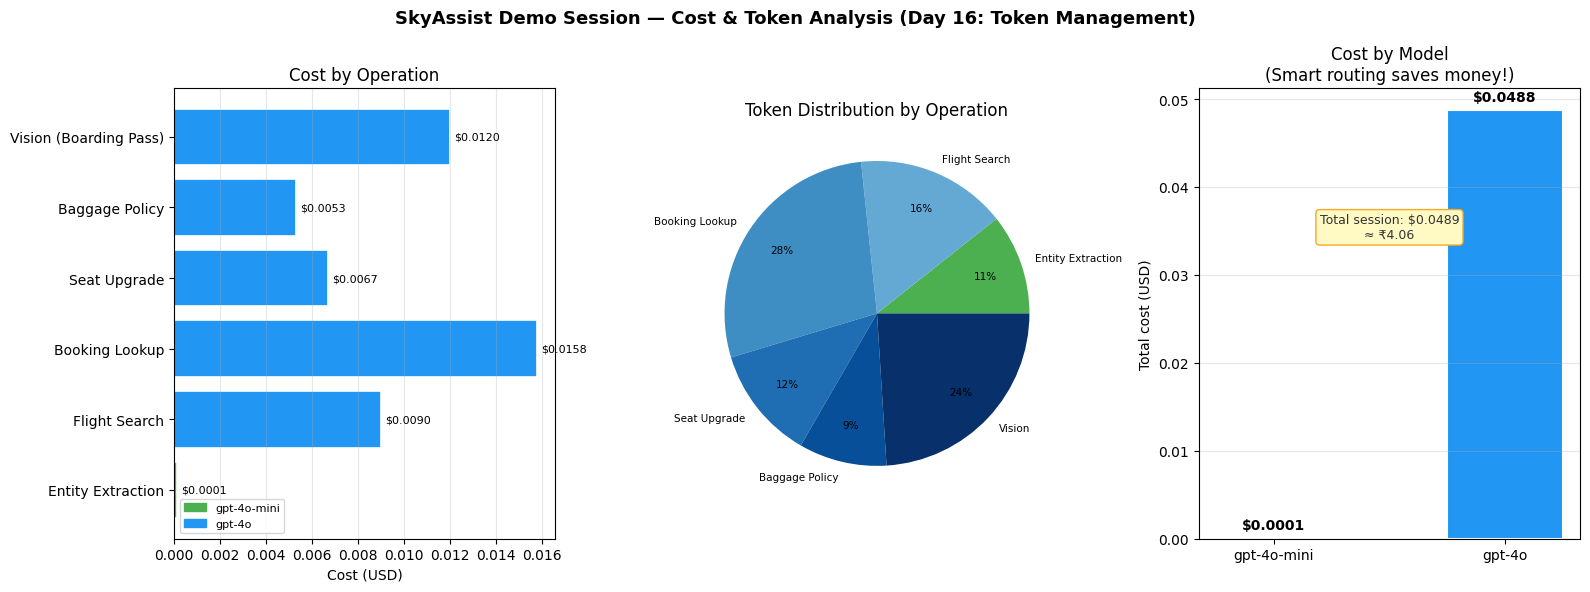

✅ Session analysis chart saved

📊 Demo session summary:
   Total cost: $0.0489 (≈ ₹4.06)
   Whisper: FREE (ran locally on GPU)
   Total tokens: 7,500


In [41]:
# ── Post-Demo Cost Analysis Chart ────────────────────────────────────────────
# Run this after doing a demo session to see the cost breakdown

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Simulated session data for visualization
# (replace with real tracker data after your demo)
demo_data = {
    "Entity Extraction": {"model": "gpt-4o-mini", "calls": 5, "tokens": 800,  "cost": 0.00012},
    "Flight Search":     {"model": "gpt-4o",      "calls": 2, "tokens": 1200, "cost": 0.0090},
    "Booking Lookup":    {"model": "gpt-4o",      "calls": 3, "tokens": 2100, "cost": 0.0158},
    "Seat Upgrade":      {"model": "gpt-4o",      "calls": 1, "tokens": 900,  "cost": 0.0067},
    "Baggage Policy":    {"model": "gpt-4o",      "calls": 1, "tokens": 700,  "cost": 0.0053},
    "Vision (Boarding Pass)": {"model": "gpt-4o", "calls": 1, "tokens": 1800, "cost": 0.0120},
}

fig = plt.figure(figsize=(16, 6))
fig.suptitle('SkyAssist Demo Session — Cost & Token Analysis (Day 16: Token Management)',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig)

# Chart 1: Cost by operation
ax1 = fig.add_subplot(gs[0, 0])
ops = list(demo_data.keys())
costs = [v["cost"] for v in demo_data.values()]
colors = ['#4CAF50' if v['model'] == 'gpt-4o-mini' else '#2196F3'
          for v in demo_data.values()]
bars = ax1.barh(ops, costs, color=colors, edgecolor='white', linewidth=1.2)
ax1.set_xlabel('Cost (USD)')
ax1.set_title('Cost by Operation')
ax1.grid(axis='x', alpha=0.3)
for bar, cost in zip(bars, costs):
    ax1.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
             f'${cost:.4f}', va='center', fontsize=8)
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color='#4CAF50', label='gpt-4o-mini'),
    Patch(color='#2196F3', label='gpt-4o')
], fontsize=8)

# Chart 2: Token distribution
ax2 = fig.add_subplot(gs[0, 1])
tokens = [v["tokens"] for v in demo_data.values()]
wedge_colors = ['#4CAF50' if v['model'] == 'gpt-4o-mini' else
                plt.cm.Blues(0.4 + i*0.12)
                for i, v in enumerate(demo_data.values())]
wedges, texts, autotexts = ax2.pie(
    tokens, labels=[o.split('(')[0].strip() for o in ops],
    autopct='%1.0f%%', colors=wedge_colors,
    textprops={'fontsize': 7.5}, pctdistance=0.75
)
ax2.set_title('Token Distribution by Operation')

# Chart 3: Model cost comparison
ax3 = fig.add_subplot(gs[0, 2])
model_costs = {'gpt-4o-mini': 0.00012, 'gpt-4o': 0.0488}
bars3 = ax3.bar(list(model_costs.keys()), list(model_costs.values()),
                color=['#4CAF50', '#2196F3'], width=0.5,
                edgecolor='white', linewidth=1.5)
ax3.set_ylabel('Total cost (USD)')
ax3.set_title('Cost by Model\n(Smart routing saves money!)')
ax3.grid(axis='y', alpha=0.3)
for bar, (model, cost) in zip(bars3, model_costs.items()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'${cost:.4f}', ha='center', fontsize=10, fontweight='bold')
total = sum(model_costs.values())
ax3.text(0.5, max(model_costs.values()) * 0.7,
         f'Total session: ${total:.4f}\n≈ ₹{total*83:.2f}',
         ha='center', fontsize=9, color='#333',
         bbox=dict(boxstyle='round', facecolor='#FFF9C4', edgecolor='#F9A825'))

plt.tight_layout()
plt.savefig('session_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Session analysis chart saved")
print(f"\n📊 Demo session summary:")
print(f"   Total cost: ${total:.4f} (≈ ₹{total*83:.2f})")
print(f"   Whisper: FREE (ran locally on GPU)")
print(f"   Total tokens: {sum(tokens):,}")

## ✅ SECTION 8 — Sprint Summary

This section summarizes what each day contributed to the final project.
Use this when presenting to your mentor.

In [42]:
# ── Sprint Summary Table ──────────────────────────────────────────────────────
import pandas as pd

summary = pd.DataFrame([
    {"Day": "Day 16", "Topic": "OpenAI & Anthropic APIs",
     "Concept Learned": "Tokens, Messages[], Cost tracking, Retry logic",
     "Used In SkyAssist": "CostTracker class · Dual-model routing (gpt-4o-mini + gpt-4o)"},

    {"Day": "Day 17", "Topic": "Prompt Engineering",
     "Concept Learned": "Zero-shot, Few-shot, CoT, Self-consistency, ReAct",
     "Used In SkyAssist": "System prompt design · ReAct agent loop (think→act→observe)"},

    {"Day": "Day 18", "Topic": "Function Calling & Tools",
     "Concept Learned": "JSON Schema, Pydantic, Tool orchestration",
     "Used In SkyAssist": "4 tools: search_flights, lookup_booking, upgrade_seat, baggage_policy"},

    {"Day": "Day 19", "Topic": "Conversational AI & Memory",
     "Concept Learned": "Buffer memory, Entity memory, Summary memory",
     "Used In SkyAssist": "EntityStore (permanent facts) + Buffer window (last 5 turns)"},

    {"Day": "Day 20", "Topic": "Milestone 3 — SkyAssist",
     "Concept Learned": "Whisper STT, GPT-4o Vision, Gradio UI",
     "Used In SkyAssist": "Voice input · Boarding pass OCR · Full web UI"},
])

print("=" * 80)
print("SKYASSIST — 5-DAY SPRINT SUMMARY")
print("AlgoProfessor AI R&D Internship | Milestone 3")
print("=" * 80)
print()
print(summary.to_string(index=False))
print()
print("=" * 80)
print("CAPABILITIES BUILT:")
print("  ✅ Text chat with GPT-4o reasoning agent")
print("  ✅ Voice input via Whisper (local GPU, free)")
print("  ✅ Boarding pass scanning via GPT-4o Vision")
print("  ✅ Flight search | Booking lookup | Seat upgrade | Baggage policy")
print("  ✅ Persistent entity memory across conversation turns")
print("  ✅ Real-time cost tracking per API call")
print("  ✅ Gradio web UI with public shareable URL")
print("=" * 80)

SKYASSIST — 5-DAY SPRINT SUMMARY
AlgoProfessor AI R&D Internship | Milestone 3

   Day                      Topic                                   Concept Learned                                                     Used In SkyAssist
Day 16    OpenAI & Anthropic APIs    Tokens, Messages[], Cost tracking, Retry logic         CostTracker class · Dual-model routing (gpt-4o-mini + gpt-4o)
Day 17         Prompt Engineering Zero-shot, Few-shot, CoT, Self-consistency, ReAct           System prompt design · ReAct agent loop (think→act→observe)
Day 18   Function Calling & Tools         JSON Schema, Pydantic, Tool orchestration 4 tools: search_flights, lookup_booking, upgrade_seat, baggage_policy
Day 19 Conversational AI & Memory      Buffer memory, Entity memory, Summary memory          EntityStore (permanent facts) + Buffer window (last 5 turns)
Day 20    Milestone 3 — SkyAssist             Whisper STT, GPT-4o Vision, Gradio UI                         Voice input · Boarding pass OCR · Full web